<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Algopro/SentenceEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer, AutoModel
import random

In [49]:
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [50]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
sum([param.numel() for param in model.parameters()])

22713216

In [51]:
sample = ["The cat sat on the mat.", "Attention is all you need."]

enc = tokenizer(sample, padding=True, truncation=True, return_tensors="pt")

print("input_ids shape:", enc["input_ids"].shape)
print("attention_mask shape:", enc["attention_mask"].shape)

print("\nTokens for sentence 0:")
print(tokenizer.convert_ids_to_tokens(enc["input_ids"][0]))

input_ids shape: torch.Size([2, 9])
attention_mask shape: torch.Size([2, 9])

Tokens for sentence 0:
['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']


In [52]:
with torch.no_grad():
    enc = enc.to(device)
    out = model(**enc)

# last_hidden_state: (batch, seq_len, hidden_size)
print("Token embeddings shape:", out.last_hidden_state.shape)

Token embeddings shape: torch.Size([2, 9, 384])


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0]], device='cuda:0')

In [43]:
def mean_pool(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).float() 
    summed = (token_embeddings * mask).sum(dim=1)  
    counts = mask.sum(dim=1).clamp(min=1e-9)      
    return summed / counts

with torch.no_grad():
    sentence_emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
print("Sentence embeddings shape:", sentence_emb.shape)

Sentence embeddings shape: torch.Size([2, 384])


In [58]:
@torch.no_grad()
def encode(texts, batch_size=64):
    # encode a list of strings into L2-normalized sentence embeddings
    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        # tokenize batch
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)

        out = model(**enc)

        # mean pool
        emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
        # L2 normalize
        emb = F.normalize(emb, dim=1)

        all_emb.append(emb.cpu())

    return torch.cat(all_emb, dim=0)

# similar sentences should have high cosine sim
test = [
    "I love pizza.",
    "Pizza is my favorite food.",
    "The stock market crashed today.",
]

e = encode(test)

print("Norms (should all be 1.0):", e.norm(dim=1))

# cosine similarity
sim = e @ e.T

print("\nSimilarity matrix:")
print(sim.numpy().round(3))

Norms (should all be 1.0): tensor([1.0000, 1.0000, 1.0000])

Similarity matrix:
[[ 1.     0.889  0.029]
 [ 0.889  1.    -0.006]
 [ 0.029 -0.006  1.   ]]


In [59]:
from datasets import load_dataset

ds = load_dataset("ag_news", split="train")
N_CORPUS = 5000
indices = random.sample(range(len(ds)), N_CORPUS)
corpus_texts = [ds[i]["text"] for i in indices]
corpus_labels = [ds[i]["label"] for i in indices]
label_names = ["World", "Sports", "Business", "Sci/Tech"]

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 81514.02 examples/s]


In [60]:
corpus_emb = encode(corpus_texts, batch_size=128)
print(f"Corpus embedding shape: {corpus_emb.shape}")

Corpus embedding shape: torch.Size([5000, 384])


In [81]:
def search(query, corpus_emb, corpus_texts, k=5):
    q = encode(query)              
    scores = q @ corpus_emb.T      

    scores, idxs = torch.topk(scores, k=k)

    results = [
        (scores[0][i].item(), corpus_texts[idxs[0][i].item()])
        for i in range(k)
    ]

    return results
for query in [
    "soccer world cup final",
    "new smartphone release",
    "stock market crash",
    "elections in europe",
]:
    print(f"\nQuery: {query}")
    for score, text in search(query, corpus_emb, corpus_texts, k=3):
        print(f"  {score:.3f}  {text}")


Query: soccer world cup final
  0.432  Football: US-Jamaica CONCACAF Semifinal Qualifier Ends in Draw Second-half substitute Brian Ching scored the first goal of his international career in the 89th minute to give the United States national soccer team a 1-1 come-from-behind draw against Jamaica in Kingston. 
  0.426  Soccer: U.S. Overcomes El Salvador After Bad-Tempered Battle  FOXBORO, Massachusetts (Reuters) - Brian Ching and Landon  Donovan scored well-taken goals as the United States beat  10-man El Salvador 2-0 in an ill-tempered CONCACAF zone Group A  World Cup qualifier on Saturday.
  0.419  Spain announce Davis Cup line-up Spain have named an unchanged team for the Davis Cup final against the United States in Seville on 3-5 December. Carlos Moya, Juan Carlos Ferrero, Rafael Nadal and Tommy Robredo will take on the US in front of 22,000 fans at the converted Olympic stadium.

Query: new smartphone release
  0.535  Nokia Says Handset Market to Slow, Share to Rise Nokia (NOK1V.H

In [92]:
def search_with_examples(example_texts, corpus_emb, corpus_texts, k=5):
    example_emb = encode(example_texts)

    # average embeddings
    prototype = example_emb.mean(dim=0, keepdim=True)
    # renormalize
    prototype = F.normalize(prototype, dim=1)

    scores = prototype @ corpus_emb.T

    scores, idxs = torch.topk(scores, k=k)

    results = [
        (scores[0][i].item(), corpus_texts[idxs[0][i].item()])
        for i in range(k)
    ]
    return results

# define a concept by multiple examples, not a single query
space_examples = [
    "NASA launched a new satellite into orbit.",
    "Astronauts returned from the space station.",
    "The Mars rover sent back new photos.",
]

for score, text in search_with_examples(space_examples, corpus_emb, corpus_texts, k=5):
    print(f"{score:.3f}  {text}")

0.540  Two Back on Earth After Six Months on Space Station Two astronauts who spent half a year aboard the International Space Station returned safely on Saturday to the steppes of Kazakhstan in the predawn darkness.
0.507  Send astronauts to repair Hubble The Hubble Space Telescope, arguably one of the greatest achievements of the space program, needs to be rescued. And astronauts should be sent to do the job.
0.478  Russia, NASA OK Space Station #39;s Next Crew MOSCOW - Russia #39;s Federal Space Agency and NASA (news - web sites) have approved the crew of the next mission to the international space station, a Russian agency spokesman said Tuesday.
0.477  NASA Puts Hands-Free Linkup to a Test Ever since two Gemini spacecraft met up high above Earth in 1965, the US space program has used astronauts for every rendezvous in orbit -- with other spacecraft, satellites, space stations or the Hubble Space Telescope.
0.474  Report urges shuttle mission to service Hubble WASHINGTON: An expert

In [95]:
def odd_one_out(texts):
    emb = encode(texts)
    sim = emb @ emb.T

    # for each item, average similarity to *others* (exclude self)
    N = sim.size(0)
    sim_no_self = sim.fill_diagonal_(0)

    mean_sim = sim_no_self.sum(dim=1) / (N - 1)
    odd_idx = mean_sim.argmin()

    return odd_idx, mean_sim

candidates = [
    "The cat is sleeping on the couch.",
    "My dog loves to play fetch in the park.",
    "Our hamster runs on its wheel every night.",
    "The quarterly earnings report exceeded expectations.",
    "I just adopted a kitten from the shelter.",
]

idx, scores = odd_one_out(candidates)
for i, (t, s) in enumerate(zip(candidates, scores.tolist())):
    mark = " | odd one out" if i == idx else ""
    print(f"{s:.3f}  {t}{mark}")

0.086  The cat is sleeping on the couch.
0.168  My dog loves to play fetch in the park.
0.166  Our hamster runs on its wheel every night.
-0.006  The quarterly earnings report exceeded expectations. | odd one out
0.189  I just adopted a kitten from the shelter.


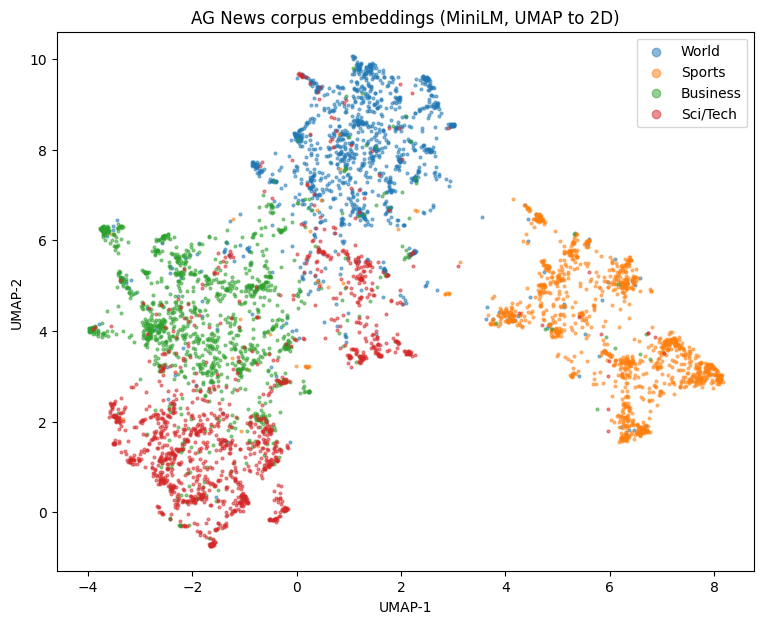

In [93]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP()
coords = reducer.fit_transform(corpus_emb)

plt.figure(figsize=(9, 7))
for label_id, name in enumerate(label_names):
    mask = np.array(corpus_labels) == label_id
    plt.scatter(coords[mask, 0], coords[mask, 1], s=4, alpha=0.5, label=name)
plt.legend(markerscale=3)
plt.title("AG News corpus embeddings (MiniLM, UMAP to 2D)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

In [134]:
K = 4
N_ITERS = 20

init_indices = torch.randint(N_CORPUS, (K,))
centroids = corpus_emb[init_indices]
scores = corpus_emb @ centroids.T
assignments = scores.argmax(dim=1)
centroids.shape

torch.Size([4, 384])

In [157]:
K = 4
N_ITERS = 20

# pick K random points from the corpus as starting prototypes
init_indices = torch.randperm(N_CORPUS)[:K]
centroids = corpus_emb[init_indices]

for it in range(N_ITERS):
    # assignment step: each point -> nearest centroid (by cosine sim)
    scores = corpus_emb @ centroids.T
    assignments = scores.argmax(dim=1)

    # update step: new centroid = mean of assigned points, then renormalize
    new_centroids = torch.zeros_like(centroids)
    for k in range(K):
        mask = (assignments == k)

        # make sure k has assignments
        if mask.sum() > 0:
            new_centroids[k] = corpus_emb[mask].mean(dim=0)[0]
        else:
            # empty cluster, reinitialize randomly
            new_centroids[k] = corpus_emb[torch.randint(0, N_CORPUS, (1,))]

    # normalizw
    new_centroids = F.normalize(new_centroids, dim=1)

    # check convergence, how much did centroids move?
    shift = (centroids - new_centroids).abs().sum()

    centroids = new_centroids

    print(f"iter {it+1:2d} max centroid shift: {shift:.4f}")
    if shift < 1e-4:
        print("converged")
        break

# cluster sizes
print("\nCluster sizes:")
for k in range(K):
    print(f"  cluster {k}: {(assignments == k).sum().item()} docs")

iter  1 max centroid shift: 92.1946
iter  2 max centroid shift: 61.8957
iter  3 max centroid shift: 140.2794
iter  4 max centroid shift: 117.5755
iter  5 max centroid shift: 45.5503
iter  6 max centroid shift: 123.9340
iter  7 max centroid shift: 101.1666
iter  8 max centroid shift: 22.7829
iter  9 max centroid shift: 22.6995
iter 10 max centroid shift: 22.6995
iter 11 max centroid shift: 0.0000
converged

Cluster sizes:
  cluster 0: 1341 docs
  cluster 1: 1300 docs
  cluster 2: 1406 docs
  cluster 3: 953 docs


In [158]:
print("Label composition of each cluster:")
print(f"{'cluster':>8} | " + " ".join(f"{n:>10s}" for n in label_names))
true_labels = np.array(corpus_labels)
for k in range(K):
    mask = (assignments == k).numpy()

    counts = [((true_labels == c) & mask).sum() for c in range(len(label_names))]

    total = sum(counts)

    pct = [100*c/total if total > 0 else 0 for c in counts]

    print(f"{k:>8} | " + " ".join(f"{p:>9.1f}%" for p in pct))

cluster_to_label = []
for k in range(K):
    mask = (assignments == k).numpy()

    if mask.sum() > 0:
        dominant = np.bincount(true_labels[mask], minlength=len(label_names)).argmax()
    else:
        dominant = 0

    cluster_to_label.append(dominant)

mapped_preds = np.array([cluster_to_label[a] for a in assignments.tolist()])
purity = (mapped_preds == true_labels).mean()

print(f"\nCluster purity: {100*purity:.1f}%")

Label composition of each cluster:
 cluster |      World     Sports   Business   Sci/Tech
       0 |      23.2%      24.5%      23.7%      28.6%
       1 |      26.2%      23.5%      26.3%      24.1%
       2 |      27.5%      25.2%      26.0%      21.2%
       3 |      21.7%      21.9%      23.7%      32.6%

Cluster purity: 28.5%


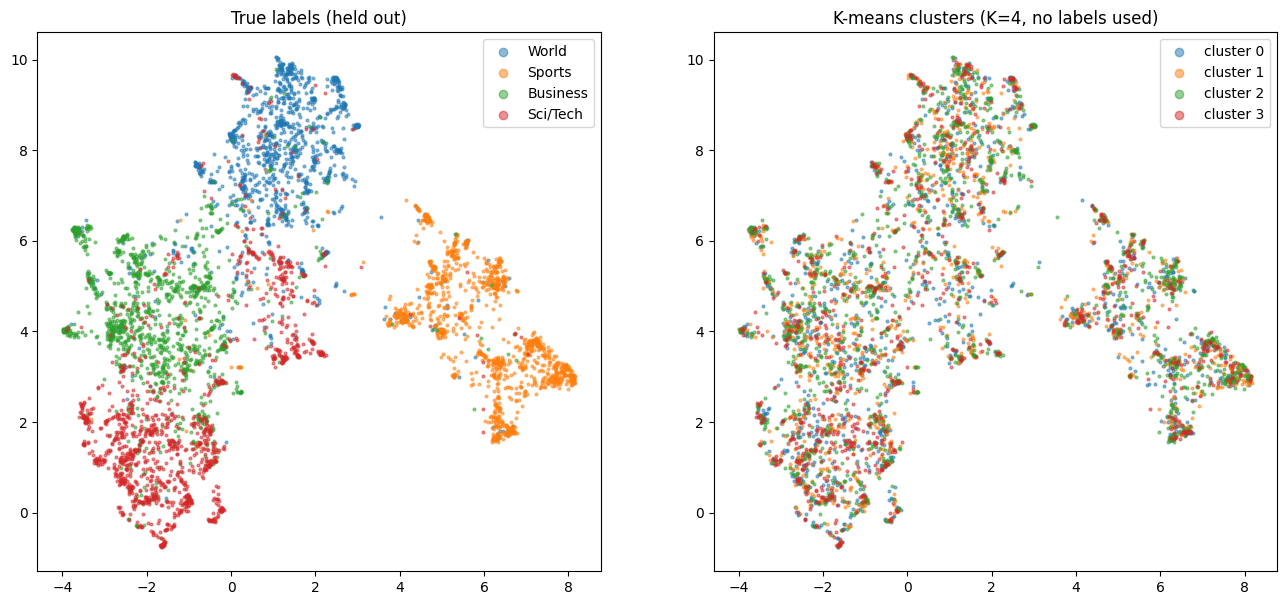

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left: true labels
for label_id, name in enumerate(label_names):
    mask = np.array(corpus_labels) == label_id
    axes[0].scatter(coords[mask, 0], coords[mask, 1], s=4, alpha=0.5, label=name)
axes[0].legend(markerscale=3)
axes[0].set_title("True labels (held out)")

# right: our cluster assignments
for k in range(K):
    mask = (assignments == k).numpy()
    axes[1].scatter(coords[mask, 0], coords[mask, 1], s=4, alpha=0.5, label=f"cluster {k}")
axes[1].legend(markerscale=3)
axes[1].set_title(f"K-means clusters (K={K}, no labels used)")

plt.show()